In [1]:
import pandas as pd

df = pd.read_csv('spotify-tracks-dataset.csv')
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]

print(df.head())

                 track_id                 artists  \
0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826     False   
3  Can't Help Falling In Love          71       201933     False   
4   

In [2]:
print(df.shape)
df.info()

(114000, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence

In [3]:
feature_cols = [
    'danceability',
    'energy',
    'valence',
    'tempo',
    'loudness',
    'acousticness',
    'instrumentalness',
    'speechiness',
]

df = df.dropna(subset=feature_cols).copy()
features = df[feature_cols]

df.info()
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [4]:
track = df['track_genre'].value_counts()
print(track)

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
trance         1000
trip-hop       1000
turkish        1000
world-music    1000
Name: count, Length: 114, dtype: int64


In [5]:
features = df[['danceability',
    'energy',
    'valence',
    'tempo',
    'loudness',
    'acousticness',
    'instrumentalness',
    'speechiness',]]

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(features)

In [9]:
if 'cluster' not in df.columns:
    features = df[feature_cols].dropna().copy()
    df = df.loc[features.index].copy()
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X = scaler.fit_transform(features)
    kmeans = KMeans(n_clusters=7, random_state=0, n_init='auto').fit(X)
    df['cluster'] = kmeans.labels_

cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(cluster_centers, columns=features.columns)

def build_cluster_name(center):
    if center['acousticness'] > 0.6 and center['energy'] < 0.5:
        return 'Acoustic Chill'
    if center['instrumentalness'] > 0.6 and center['valence'] < 0.45:
        return 'Sad Instrumental'
    if center['energy'] > 0.75 and center['tempo'] > 125:
        return 'High Tempo'
    if center['danceability'] > 0.72 and center['speechiness'] > 0.12:
        return 'Hip-Hop'
    if center['valence'] > 0.62 and center['energy'] > 0.6:
        return 'Happy Vibes'
    if center['valence'] < 0.4 and center['energy'] < 0.55:
        return 'Melancholic'
    return 'Dark Electronic'

cluster_labels = {
    cluster_id: build_cluster_name(center)
    for cluster_id, center in centers_df.iterrows()
}

df['cluster_name'] = df['cluster'].map(cluster_labels)

df[['track_name', 'artists', 'cluster_name']].head(10)

,track_name,artists,cluster_name
0,Comedy,Gen Hoshino,Happy Vibes
1,Ghost - Acoustic,Ben Woodward,Acoustic Chill
2,To Begin Again,Ingrid Michaelson;ZAYN,Acoustic Chill
3,Can't Help Falling In Love,Kina Grannis,Acoustic Chill
4,Hold On,Chord Overstreet,Acoustic Chill
5,Days I Will Remember,Tyrone Wells,Happy Vibes
6,Say Something,A Great Big World;Christina Aguilera,Acoustic Chill
7,I'm Yours,Jason Mraz,Happy Vibes
8,Lucky,Jason Mraz;Colbie Caillat,Happy Vibes
9,Hunger,Ross Copperman,Acoustic Chill


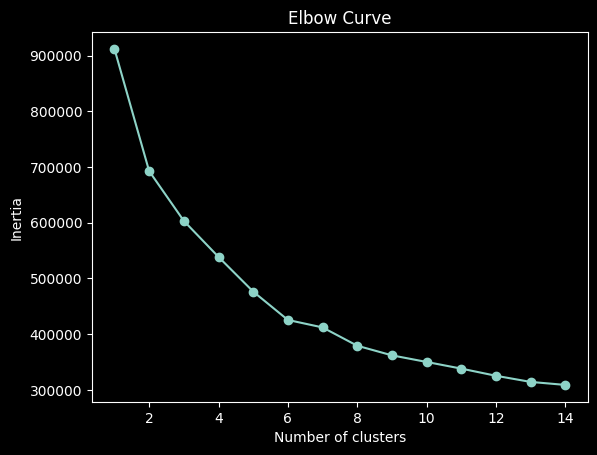

In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(1, 15)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=0, n_init='auto')
    kmeans_test.fit(X)
    inertias.append(kmeans_test.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.show()

In [11]:
features = df[feature_cols].dropna().copy()
df = df.loc[features.index].copy()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=7, random_state=0, n_init='auto').fit(X)
df['cluster'] = kmeans.labels_

print(df.groupby('cluster')[['danceability',
                             'energy',
                             'valence',
                             'tempo',
                             'loudness',
                             'acousticness',
                             'instrumentalness',
                             'speechiness']].mean())

         danceability    energy   valence       tempo   loudness  \
cluster                                                            
0            0.469940  0.814246  0.372722  139.114531  -5.398281   
1            0.696345  0.731322  0.700814  117.823515  -6.332490   
2            0.603775  0.358665  0.371774  116.743938 -13.726832   
3            0.272965  0.143847  0.140118   98.519409 -23.074035   
4            0.651807  0.658538  0.510453  118.294672  -8.279202   
5            0.564114  0.800675  0.324318  128.423490  -7.702530   
6            0.523665  0.382764  0.390971  113.017752 -10.569767   

         acousticness  instrumentalness  speechiness  
cluster                                               
0            0.077721          0.027903     0.078570  
1            0.211750          0.018887     0.075763  
2            0.665122          0.812709     0.063992  
3            0.871776          0.767929     0.047927  
4            0.404528          0.020547     0.483163  
5 

In [12]:
def song_search(song, artists):
    result = df[df['track_name'].str.contains(song, na=False, case=False, regex=False) & df['artists'].str.contains(artists, na=False, case=False, regex=False)]
    result = result.drop_duplicates(subset=['track_name', 'artists'])
    result = result [['track_name', 'artists', 'cluster_name', 'energy', 'tempo', 'valence', 'danceability', 'acousticness',]]
    return result

print(song_search("Paranoid", "Black Sabbath"))

                       track_name        artists cluster_name  energy  \
47105  Paranoid (2009 - Remaster)  Black Sabbath   High Tempo   0.685   
47457  Paranoid (2012 - Remaster)  Black Sabbath   High Tempo   0.647   

         tempo  valence  danceability  acousticness  
47105  162.780    0.328         0.423      0.000063  
47457  163.047    0.409         0.415      0.000041  


In [13]:
import numpy as np
np.random.seed(42)

def get_similar (cluster):
    similar = df[df['cluster_name'] == cluster]
    n = min(5, len(similar))
    if n > 0:
        similar = similar.sample(n=n, random_state=42)
    similar = similar[['track_name', 'artists', 'cluster_name', 'energy', 'tempo', 'valence', 'danceability', 'acousticness',]]
    return similar

print(get_similar('High Tempo'))

                                              track_name  \
63130                                          NOT FOUND   
85593                                   Hospodo nalejvej   
5002                                           KICK BACK   
40513  Não Há Outro Lugar (feat. Alessandro Vilas Boa...   
42537                           Intimate Slavery (Remix)   

                                          artists cluster_name  energy  \
63130                                 Mr.Children   High Tempo   0.695   
85593                                     Alkehol   High Tempo   0.913   
5002                                Kenshi Yonezu   High Tempo   0.941   
40513  Central 3;Pevê Brito;Alessandro Vilas Boas   High Tempo   0.531   
42537                               Pig Destroyer   High Tempo   0.948   

         tempo  valence  danceability  acousticness  
63130  121.876   0.2740         0.323      0.007240  
85593  150.073   0.6880         0.583      0.005160  
5002   101.921   0.2920         

In [14]:
def song_analyze (song, artists):
    search = song_search(song, artists)
    if search.empty:
        return search, None
    cluster = search['cluster_name'].iloc[0]
    similar = get_similar(cluster)
    return search, similar

track_info, similar = song_analyze("Paranoid", "Black Sabbath")

if track_info.empty:
    print('No tracks found')
else:
    print("Track info:")
    print(track_info)
    print("\nSimilar tracks:")
    print(similar)

Track info:
                       track_name        artists cluster_name  energy  \
47105  Paranoid (2009 - Remaster)  Black Sabbath   High Tempo   0.685   
47457  Paranoid (2012 - Remaster)  Black Sabbath   High Tempo   0.647   

         tempo  valence  danceability  acousticness  
47105  162.780    0.328         0.423      0.000063  
47457  163.047    0.409         0.415      0.000041  

Similar tracks:
                                              track_name  \
63130                                          NOT FOUND   
85593                                   Hospodo nalejvej   
5002                                           KICK BACK   
40513  Não Há Outro Lugar (feat. Alessandro Vilas Boa...   
42537                           Intimate Slavery (Remix)   

                                          artists cluster_name  energy  \
63130                                 Mr.Children   High Tempo   0.695   
85593                                     Alkehol   High Tempo   0.913   
5002  

In [15]:
import json
import joblib
joblib.dump(kmeans, 'kmeans.pkl')
joblib.dump(scaler, 'scaler.pkl')
with open('cluster_labels.json', 'w', encoding='utf-8') as f:
    json.dump(cluster_labels, f, ensure_ascii=False, indent=2)

df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
df.to_csv('tracks_with_clusters.csv', index=False)